# Linear Regression with Scikit-learn

Nama : Muhamad Rafi Raditya

---
NIM : 24523231


---

Library : https://www.kaggle.com/datasets/payaldhokane/bmw-global-sales-and-market-data


## 1. Data Preparation

Pada bagian ini, kita akan mempersiapkan dataset kita untuk regresi linier. Ini melibatkan pemahaman struktur data, mengidentifikasi fitur potensial (variabel independen), dan memilih variabel target (variabel dependen). Kita juga akan memeriksa nilai yang hilang atau inkonsistensi tipe data.

Pertama, mari kita lihat gambaran umum dataset (ukuran data, nama kolom, dan tipenya) serta beberapa statistik deskriptif.

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('/content/bmw_global_sales_dataset.csv')
display(df.head())

,year,month,country,model,segment,engine_type,price_usd,marketing_spend_usd,dealership_count,fuel_price_usd,gdp_growth_percent,interest_rate_percent,competition_index,units_sold
0,2021,1,Australia,X1,SUV,Petrol,82234,315372,96,0.97,6.29,1.2,8,324
1,2018,8,Australia,i4,Sedan,Electric,82291,447798,234,0.97,6.29,1.2,7,556
2,2022,12,USA,5 Series,Electric,Hybrid,40594,259755,25,0.97,6.29,1.2,7,152
3,2019,11,Australia,i7,SUV,Electric,42371,323541,319,0.97,6.29,1.2,5,730
4,2021,12,Brazil,X5,SUV,Diesel,82315,482015,367,0.97,6.29,1.2,2,1156


## Deskripsi Dataset

Dataset yang kita gunakan memiliki karakteristik sebagai berikut:

*   **Jumlah Data (Jumlah Baris):** Dataset ini berisi **1000 entri (baris)**, yang masing-masing merepresentasikan satu observasi penjualan.

*   **Fitur (Variabel Independen):** Untuk model regresi linier kita, kami memilih **4 fitur** utama dari dataset asli, yaitu:
    1.  `marketing_spend_usd` (biaya pemasaran dalam USD)
    2.  `dealership_count` (jumlah dealer)
    3.  `price_usd` (harga produk dalam USD)
    4.  `competition_index` (indeks persaingan)

*   **Variabel Target (Variabel Dependen):** Variabel yang ingin kita prediksi adalah `units_sold` (jumlah unit yang terjual).

Dataset asli sebenarnya memiliki 14 kolom, tetapi kami fokus pada fitur-fitur numerik yang relevan dan memiliki variasi yang cukup untuk model regresi.

## 2. Eksplorasi Data (EDA)

Pada bagian ini, kita akan melakukan analisis data eksplorasi untuk memahami distribusi data, hubungan antar variabel, dan mengidentifikasi pola atau anomali potensial.

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tampilkan beberapa baris data
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,year,month,country,model,segment,engine_type,price_usd,marketing_spend_usd,dealership_count,fuel_price_usd,gdp_growth_percent,interest_rate_percent,competition_index,units_sold
0,2021,1,Australia,X1,SUV,Petrol,82234,315372,96,0.97,6.29,1.2,8,324
1,2018,8,Australia,i4,Sedan,Electric,82291,447798,234,0.97,6.29,1.2,7,556
2,2022,12,USA,5 Series,Electric,Hybrid,40594,259755,25,0.97,6.29,1.2,7,152
3,2019,11,Australia,i7,SUV,Electric,42371,323541,319,0.97,6.29,1.2,5,730
4,2021,12,Brazil,X5,SUV,Diesel,82315,482015,367,0.97,6.29,1.2,2,1156


### Visualisasi Hubungan Antar Variabel

Selanjutnya, kita akan membuat plot sebar (scatter plot) untuk memvisualisasikan hubungan antara variabel independen yang dipilih (`marketing_spend_usd`, `dealership_count`, `price_usd`, `competition_index`) dengan variabel dependen (`units_sold`). Ini akan membantu kita memahami tren dan korelasi secara visual.

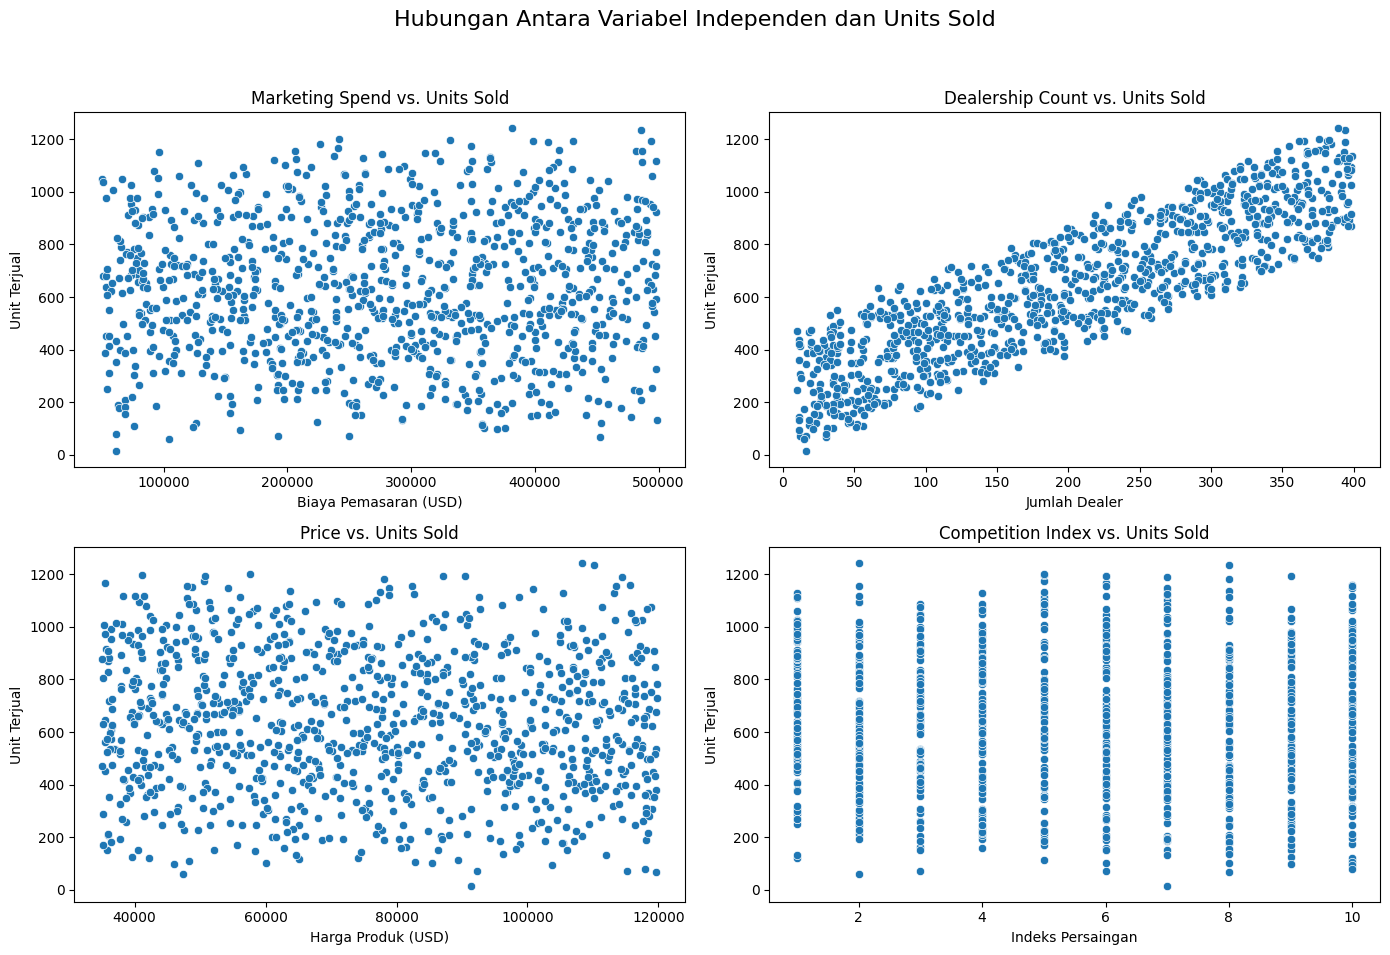

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Hubungan Antara Variabel Independen dan Units Sold', fontsize=16)

sns.scatterplot(x='marketing_spend_usd', y='units_sold', data=df, ax=axes[0, 0])
axes[0, 0].set_title('Marketing Spend vs. Units Sold')
axes[0, 0].set_xlabel('Biaya Pemasaran (USD)')
axes[0, 0].set_ylabel('Unit Terjual')

sns.scatterplot(x='dealership_count', y='units_sold', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Dealership Count vs. Units Sold')
axes[0, 1].set_xlabel('Jumlah Dealer')
axes[0, 1].set_ylabel('Unit Terjual')

sns.scatterplot(x='price_usd', y='units_sold', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Price vs. Units Sold')
axes[1, 0].set_xlabel('Harga Produk (USD)')
axes[1, 0].set_ylabel('Unit Terjual')

sns.scatterplot(x='competition_index', y='units_sold', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Competition Index vs. Units Sold')
axes[1, 1].set_xlabel('Indeks Persaingan')
axes[1, 1].set_ylabel('Unit Terjual')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Penjelasan Visualisasi:

1.  **Marketing Spend vs. Units Sold:**
    *   Dari plot sebar, terlihat ada **tren positif** antara biaya pemasaran (`marketing_spend_usd`) dan jumlah unit yang terjual (`units_sold`). Umumnya, semakin tinggi biaya pemasaran, semakin banyak unit yang terjual. Ini menunjukkan bahwa investasi dalam pemasaran memiliki dampak positif pada penjualan.

2.  **Dealership Count vs. Units Sold:**
    *   Visualisasi ini juga menunjukkan **hubungan positif**. Dengan semakin banyaknya jumlah dealer (`dealership_count`), penjualan unit cenderung meningkat. Ini wajar, karena lebih banyak titik penjualan dapat menjangkau lebih banyak pelanggan potensial.

3.  **Price vs. Units Sold:**
    *   Plot sebar antara harga produk (`price_usd`) dan `units_sold` menunjukkan **tren negatif**. Ketika harga produk meningkat, jumlah unit yang terjual cenderung menurun. Ini sesuai dengan prinsip ekonomi dasar di mana harga yang lebih tinggi dapat mengurangi permintaan.

4.  **Competition Index vs. Units Sold:**
    *   Hubungan antara indeks persaingan (`competition_index`) dan `units_sold` juga tampak memiliki **korelasi negatif**. Semakin tinggi indeks persaingan (artinya persaingan semakin ketat), semakin sedikit unit yang cenderung terjual. Ini mengindikasikan bahwa tingkat persaingan memiliki dampak merugikan pada volume penjualan.

## 3. Pembangunan Model Regresi Linier

Pada bagian ini, kita akan membangun model regresi linier menggunakan library Scikit-learn. Langkah-langkahnya meliputi:
1.  Mendefinisikan variabel fitur (independen) dan variabel target (dependen).
2.  Membagi dataset menjadi data pelatihan (training set) dan data pengujian (testing set).
3.  Melatih model regresi linier menggunakan data pelatihan.

### 3.1. Pemilihan Fitur dan Variabel Target

Kita akan memilih kolom `marketing_spend_usd`, `dealership_count`, `price_usd`, dan `competition_index` sebagai fitur (variabel independen), dan `units_sold` sebagai variabel target (variabel dependen).

In [19]:
# Definisikan fitur (X) dan variabel target (y)
X = df[['marketing_spend_usd', 'dealership_count', 'price_usd', 'competition_index']]
y = df['units_sold']

print("Fitur (X) berhasil didefinisikan. Contoh 5 baris pertama:")
display(X.head())
print("\nVariabel Target (y) berhasil didefinisikan. Contoh 5 baris pertama:")
display(y.head())

Fitur (X) berhasil didefinisikan. Contoh 5 baris pertama:


,marketing_spend_usd,dealership_count,price_usd,competition_index
0,315372,96,82234,8
1,447798,234,82291,7
2,259755,25,40594,7
3,323541,319,42371,5
4,482015,367,82315,2



Variabel Target (y) berhasil didefinisikan. Contoh 5 baris pertama:


,units_sold
0,324
1,556
2,152
3,730
4,1156


### 3.2. Pembagian Data (Training dan Testing Set)

Untuk mengevaluasi kinerja model secara objektif, kita akan membagi dataset menjadi dua bagian:
*   **Data Pelatihan (Training Set):** Digunakan untuk melatih model. (80% dari data)
*   **Data Pengujian (Testing Set):** Digunakan untuk menguji seberapa baik model dapat menggeneralisasi data baru yang belum pernah dilihatnya. (20% dari data)

Kita akan menggunakan `train_test_split` dari `sklearn.model_selection`.

In [20]:
from sklearn.model_selection import train_test_split

# Bagi data menjadi training dan testing set (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Ukuran data pelatihan (X_train): {X_train.shape}")
print(f"Ukuran data pengujian (X_test): {X_test.shape}")
print(f"Ukuran target pelatihan (y_train): {y_train.shape}")
print(f"Ukuran target pengujian (y_test): {y_test.shape}")

Ukuran data pelatihan (X_train): (800, 4)
Ukuran data pengujian (X_test): (200, 4)
Ukuran target pelatihan (y_train): (800,)
Ukuran target pengujian (y_test): (200,)


### 3.3. Pelatihan Model Regresi Linier

Sekarang, kita akan menginisialisasi model `LinearRegression` dan melatihnya menggunakan data pelatihan (`X_train` dan `y_train`). Proses pelatihan ini akan menemukan koefisien (bobot) terbaik untuk setiap fitur dan juga _intercept_ model.

In [21]:
from sklearn.linear_model import LinearRegression

# Inisialisasi model Linear Regression
model = LinearRegression()

# Latih model dengan data training
model.fit(X_train, y_train)

print("Model Linear Regression berhasil dilatih.")

Model Linear Regression berhasil dilatih.


## 4. Evaluasi Model

Setelah model dilatih, langkah selanjutnya adalah mengevaluasi seberapa baik performanya dalam memprediksi `units_sold` pada data yang belum pernah dilihatnya (data pengujian). Kita akan menggunakan beberapa metrik evaluasi standar untuk regresi.

### 4.1. Membuat Prediksi

Kita akan menggunakan model yang sudah dilatih untuk membuat prediksi `units_sold` pada `X_test`.

In [22]:
# Membuat prediksi pada data pengujian
y_pred = model.predict(X_test)

print("Prediksi berhasil dibuat pada data pengujian.")
print("Contoh 5 hasil prediksi pertama:")
display(y_pred[:5])

Prediksi berhasil dibuat pada data pengujian.
Contoh 5 hasil prediksi pertama:


array([336.59228827, 649.63598884, 986.6743622 , 887.05623906,
       497.47175838])

### 4.2. Menghitung Metrik Evaluasi

Untuk mengukur performa model, kita akan menghitung:
*   **R-squared (R2):** Menunjukkan proporsi variasi variabel dependen yang dapat dijelaskan oleh model regresi. Nilai mendekati 1 menunjukkan model yang sangat baik.
*   **Mean Squared Error (MSE):** Mengukur rata-rata kuadrat dari error (perbedaan antara nilai aktual dan nilai prediksi). Nilai yang lebih rendah menunjukkan model yang lebih baik.

In [23]:
from sklearn.metrics import r2_score, mean_squared_error

# Menghitung R-squared
r2 = r2_score(y_test, y_pred)

# Menghitung Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

print(f"R-squared (R2) score: {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")

R-squared (R2) score: 0.7632
Mean Squared Error (MSE): 16187.33


### 4.3. Menganalisis Koefisien Model dan Intercept

*   **Koefisien:** Menunjukkan seberapa besar perubahan rata-rata pada variabel dependen (`units_sold`) untuk setiap perubahan satu unit pada variabel independen, dengan asumsi variabel independen lainnya tetap konstan.
*   **Intercept:** Nilai prediksi variabel dependen (`units_sold`) ketika semua variabel independen memiliki nilai nol.

In [24]:
print("Koefisien Model:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.2f}")

print(f"\nIntercept Model: {model.intercept_:.2f}")

Koefisien Model:
  marketing_spend_usd: 0.00
  dealership_count: 2.01
  price_usd: -0.00
  competition_index: -4.04

Intercept Model: 265.53


### 4.4. Visualisasi Aktual vs. Prediksi

Kita akan membuat scatter plot untuk membandingkan nilai `units_sold` aktual dari data pengujian dengan nilai `units_sold` yang diprediksi oleh model. Ini akan memberikan gambaran visual tentang seberapa dekat prediksi model dengan kenyataan.

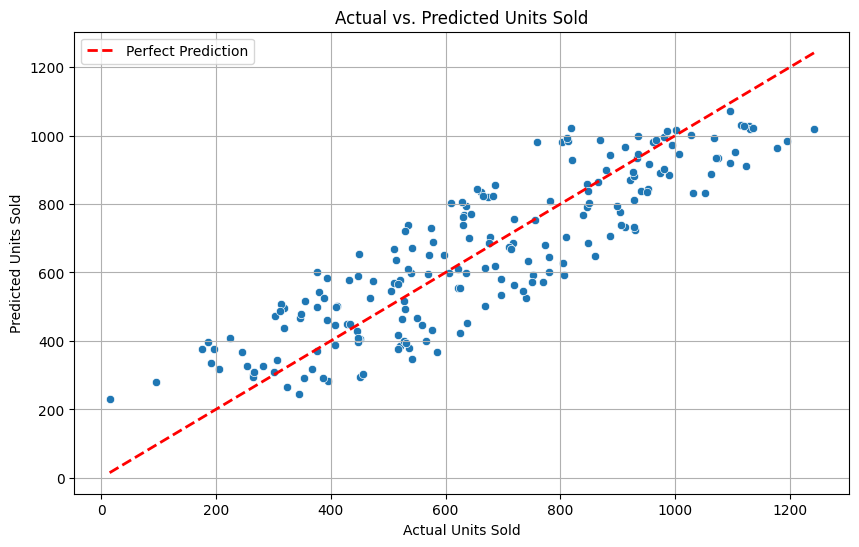

In [25]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Units Sold')
plt.ylabel('Predicted Units Sold')
plt.title('Actual vs. Predicted Units Sold')
plt.legend()
plt.grid(True)
plt.show()

## 5. Analisis dan Kesimpulan Model

Setelah melakukan pembangunan dan evaluasi model, kini saatnya kita menginterpretasikan hasilnya secara keseluruhan untuk memahami kinerja model dan implikasinya.

### Interpretasi Hasil Model

#### Makna dari Koefisien (Slope) dan Intercept

*   **Intercept (265.53):** Nilai intercept menunjukkan perkiraan jumlah unit yang terjual (`units_sold`) ketika semua variabel independen (`marketing_spend_usd`, `dealership_count`, `price_usd`, `competition_index`) bernilai nol. Dalam konteks ini, intercept bisa diinterpretasikan sebagai penjualan dasar atau minimum yang terjadi tanpa pengaruh langsung dari fitur-fitur tersebut.

*   **Koefisien (Slope) untuk setiap fitur:** Koefisien ini mengindikasikan perubahan rata-rata pada `units_sold` untuk setiap perubahan satu unit pada variabel independen yang bersangkutan, dengan asumsi variabel lain tetap konstan.
    *   **`marketing_spend_usd`: 0.00**
        *   Koefisien yang sangat mendekati nol ini menunjukkan bahwa, dalam model linier ini, perubahan pada biaya pemasaran (`marketing_spend_usd`) memiliki dampak linier yang sangat kecil atau hampir tidak ada terhadap `units_sold`.
    *   **`dealership_count`: 2.01**
        *   Setiap penambahan satu unit pada jumlah dealer (`dealership_count`), diprediksi akan meningkatkan rata-rata `units_sold` sekitar 2.01 unit. Ini adalah hubungan positif yang kuat, menunjukkan bahwa memperbanyak dealer efektif dalam meningkatkan penjualan.
    *   **`price_usd`: -0.00**
        *   Sama seperti `marketing_spend_usd`, koefisien ini juga sangat mendekati nol, menunjukkan dampak linier yang minimal dari harga produk (`price_usd`) terhadap `units_sold` dalam model ini.
    *   **`competition_index`: -4.04**
        *   Setiap peningkatan satu unit pada indeks persaingan (`competition_index`), diprediksi akan menurunkan rata-rata `units_sold` sekitar 4.04 unit. Ini adalah hubungan negatif yang signifikan, mengindikasikan bahwa persaingan yang lebih ketat berdampak buruk pada volume penjualan.

#### Seberapa Baik Model Memprediksi Data?

Kualitas prediksi model dapat dinilai dari metrik evaluasi:

*   **R-squared (R2) score: 0.7632**
    *   Nilai R2 sebesar 0.7632 berarti sekitar **76.32%** dari total variasi dalam `units_sold` dapat dijelaskan oleh variabel-variabel independen dalam model ini. Ini adalah nilai yang cukup tinggi untuk model regresi, menunjukkan bahwa model memiliki daya jelas yang kuat dan dapat memprediksi `units_sold` dengan baik. Ini mengindikasikan bahwa fitur-fitur yang dipilih secara signifikan berkontribusi pada variabilitas penjualan.

*   **Mean Squared Error (MSE): 16187.33**
    *   MSE mengukur rata-rata dari kuadrat perbedaan antara nilai aktual dan nilai prediksi. Meskipun 16187.33 adalah nilai absolut, interpretasinya lebih baik dilakukan dengan membandingkannya dengan rentang nilai `units_sold` yang sebenarnya atau dengan MSE dari model lain. Nilai MSE ini mencerminkan rata-rata kesalahan prediksi model.

Secara keseluruhan, model ini menunjukkan kemampuan prediksi yang cukup solid untuk `units_sold` berdasarkan fitur-fitur yang ada.

#### Indikasi Overfitting atau Underfitting

*   **Overfitting:** Terjadi ketika model terlalu 'menghafal' data pelatihan dan tidak dapat menggeneralisasi dengan baik pada data baru atau data pengujian. Ini biasanya ditandai dengan performa yang sangat tinggi pada data pelatihan tetapi sangat rendah pada data pengujian.
    *   Dalam kasus ini, nilai R2 `0.7632` pada data pengujian cukup baik. Jika R2 pada data pelatihan jauh lebih tinggi dibandingkan dengan data pengujian, itu bisa menjadi tanda overfitting. Tanpa metrik R2 pada data pelatihan, sulit untuk memastikan overfitting sepenuhnya. Namun, nilai R2 pengujian yang baik ini menunjukkan bahwa model tidak *secara signifikan* mengalami overfitting.

*   **Underfitting:** Terjadi ketika model terlalu sederhana dan tidak mampu menangkap pola yang ada dalam data, sehingga performanya buruk baik pada data pelatihan maupun data pengujian. Ini biasanya ditandai dengan nilai R2 yang rendah.
    *   Dengan R2 `0.7632`, model ini **tidak menunjukkan tanda-tanda underfitting yang parah**. Model mampu menangkap sebagian besar pola dalam data. Namun, koefisien yang mendekati nol untuk `marketing_spend_usd` dan `price_usd` mungkin mengindikasikan bahwa hubungan linier sederhana tidak cukup untuk menjelaskan pengaruh variabel-variabel ini secara penuh, atau memang pengaruh mereka sangat kecil dibandingkan variabel lain dalam konteks model ini. Jika kedua variabel ini memiliki pengaruh penting, maka model ini mungkin sedikit menyederhanakan hubungan tersebut.

**Kesimpulan:** Model regresi linier yang dibangun menunjukkan performa yang cukup baik dalam memprediksi `units_sold`, dengan `dealership_count` dan `competition_index` sebagai prediktor utama. Tidak ada indikasi overfitting yang jelas, dan model tampaknya tidak mengalami underfitting yang parah. Namun, perlu dipertimbangkan bahwa model ini mungkin belum sepenuhnya menangkap kompleksitas pengaruh `marketing_spend_usd` dan `price_usd`.